# DL challenge

In [1]:
import os
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory

class_names = [
    "Black_spiny_tailed_iguana",
    "Brown_anole",
    "Cuban_knight_anole",
    "Desert_iguana",
    "Green_anole",
    "Green_iguana",
    "Lesser_Antillean_iguana"
]

NUM_CLASSES = 7

### Exploratory Data Analysis (EDA) & Dataset Cleaning

We begonnen het project met een grondige Exploratory Data Analysis (EDA) van de trainingsdataset. Tijdens deze analyse onderzochten we de verschillende klassen, bekeken we voorbeeldafbeeldingen en identificeerden we verwarrende of fout gelabelde foto’s. Vooral bij visueel gelijkaardige soorten, zoals Green Iguana en Lesser Antillean Iguana, zorgden mislabeled images voor extra moeilijkheden.

Om de kwaliteit van de dataset te verbeteren, hebben we handmatig verwarrende, foutieve of inconsistente afbeeldingen uit de trainingsset verwijderd. Dit zorgde voor duidelijkere klassengrenzen, minder ruis in de data en uiteindelijk betere modelprestaties tijdens training en validatie.

### Configuratie & Flexibiliteit

Om experimenteren efficiënter te maken, hebben we belangrijke hyperparameters zoals `IMG_SIZE` en `batch_size` centraal bovenaan de code gedefinieerd. Hierdoor konden we afbeeldingsgrootte, batchgrootte en data augmentation instellingen eenvoudig aanpassen op één plaats, zonder meerdere codeblokken te moeten wijzigen.

Deze aanpak maakte het gemakkelijker om verschillende configuraties snel te testen, zoals grotere image sizes voor meer detail of kleinere batch sizes voor betere GPU-prestaties. Ook de data augmentation instellingen konden flexibel aangepast worden om de optimale balans tussen modelrobustheid en trainingssnelheid te vinden.

In [ ]:
IMG_SIZE = 456
batch_size = 16

# data_augmentation = tf.keras.Sequential([
#     # layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.05),
#     layers.RandomZoom(0.01),
#     layers.RandomContrast(0.05),
# ])


### Modelopbouw & Training Configuratie

Voor het classificatiemodel gebruikten we **EfficientNetB0** als pretrained base model via transfer learning. Door `weights="imagenet"` te gebruiken, startte het model met reeds aangeleerde visuele kennis uit de grote ImageNet-dataset, wat de trainingssnelheid verhoogde en betere prestaties mogelijk maakte.

Met `include_top=False` verwijderden we de originele classificatielaag van EfficientNet, zodat we zelf een aangepaste outputstructuur konden bouwen voor onze 7 specifieke reptielklassen.

### Bevriezen van de Base Layers
Door `base_model.trainable = False` te gebruiken, werden de bestaande EfficientNet-lagen in eerste instantie bevroren. Hierdoor bleef de algemene feature-extractie behouden, terwijl enkel onze nieuwe classificatielagen werden getraind. Dit verminderde overfitting en zorgde voor stabielere eerste resultaten.

### Toegevoegde classificatielagen
Bovenop het base model voegden we toe:
- **Data augmentation** voor robuustere inputvariatie
- **GlobalAveragePooling2D** om features efficiënt samen te vatten
- **Dense(128, ReLU)** als extra leerlaag
- **Dense(NUM_CLASSES, Softmax)** voor multiclass classificatie over 7 soorten

### Compile instellingen
Voor training gebruikten we:
- **Adam optimizer** voor efficiënte gewichtsoptimalisatie
- **Sparse categorical crossentropy** als geschikte lossfunctie voor integer labels
- **Accuracy** als hoofdmetric om prestaties te evalueren

Deze structuur bood een sterke combinatie van pretrained kennis, flexibiliteit en classificatiekracht.

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    # data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="Adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Dataset Inladen & Voorbereiding

Voor het trainen van het model gebruikten we `image_dataset_from_directory`, waarmee TensorFlow automatisch afbeeldingen uit onze trainingsmap kon inladen en labels kon afleiden op basis van de mapstructuur.

### Train / Validation Split
We verdeelden de dataset automatisch in:
- **80% training data**
- **20% validatie data**

Dit gebeurde via:
- `validation_split=0.2`
- `subset='training'` of `subset='validation'`

Door voor beide datasets dezelfde `seed=123` te gebruiken, bleef de split consistent en reproduceerbaar tijdens elke run.

### Belangrijke instellingen:
- **batch_size** bepaalt hoeveel afbeeldingen tegelijk verwerkt worden
- **image_size** zorgt ervoor dat alle afbeeldingen uniform herschaald worden naar dezelfde resolutie (`IMG_SIZE x IMG_SIZE`)
- **label_mode='int'** gebruikt numerieke klasselabels, wat compatibel is met sparse categorical crossentropy

In [4]:
train_ds = image_dataset_from_directory(
    './train',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=(IMG_SIZE, IMG_SIZE),
    validation_split=0.2,
    subset='training',
    seed=123
)

validation_ds = image_dataset_from_directory(
    './train',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=(IMG_SIZE, IMG_SIZE),
    validation_split=0.2,
    subset='validation',
    seed=123
)

Found 740 files belonging to 7 classes.
Using 592 files for training.
Found 740 files belonging to 7 classes.
Using 148 files for validation.


### Prestatie-optimalisatie
Om training efficiënter te maken, volgden we de aanbevolen optimalisaties van ChatGPT:
- **cache()** → slaat data tijdelijk op voor snellere herlaadprestaties
- **shuffle(1000)** → zorgt voor willekeurige trainingsvolgorde en betere generalisatie
- **prefetch(AUTOTUNE)** → laadt batches vooraf in om GPU/CPU efficiënter te benutten

Deze suggesties hielpen ons om de trainingspipeline sneller en stabieler te maken, waardoor experimenteren met verschillende modelinstellingen efficiënter verliep.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(AUTOTUNE)

### Model Training & Early Stopping

Voor het trainen van het model gebruikten we `model.fit()`, waarbij de trainingsdataset (`train_ds`) werd gebruikt om het model te leren en de validatieset (`validation_ds`) werd ingezet om prestaties op ongeziene data te controleren.

### Trainingsinstellingen:
- **epochs=20** → maximaal 20 trainingsrondes
- **validation_data** → controle op validatieprestaties na elke epoch
- **history** → slaat accuracy- en losswaarden op voor latere visualisatie

### Early Stopping
Om overfitting te beperken, gebruikten we de door ChatGPT aanbevolen `EarlyStopping` callback:

- **monitor="val_loss"** → volgt de validatie loss
- **patience=5** → stopt training automatisch als de validatie loss 5 epochs lang niet verbetert
- **restore_best_weights=True** → herstelt automatisch de beste modelgewichten

### Voordelen:
- Voorkomt onnodig lange training
- Vermindert overfitting
- Bespaart tijd en rekenkracht
- Zorgt ervoor dat het beste model automatisch behouden blijft

Deze aanpak maakte het trainingsproces efficiënter en hielp ons om betere generalisatieprestaties te behalen.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.4605 - loss: 1.4610 - val_accuracy: 0.7500 - val_loss: 0.7366
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7908 - loss: 0.5668 - val_accuracy: 0.7973 - val_loss: 0.5940
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8880 - loss: 0.3625 - val_accuracy: 0.7770 - val_loss: 0.5468
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9213 - loss: 0.2872 - val_accuracy: 0.8041 - val_loss: 0.5526
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9272 - loss: 0.2502 - val_accuracy: 0.8311 - val_loss: 0.4667
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9719 - loss: 0.1531 - val_accuracy: 0.7973 - val_loss: 0.5300
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9790 - loss: 0.1401 - val_accuracy: 0.8311 - val_loss: 0.4460
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9777 - loss: 0.0995 - val_accuracy: 0.8176 - val_loss:

### Model Evaluatie & Confusion Matrix Analyse

Na training voerden we een aparte evaluatie uit op de validatieset om de prestaties van het model gedetailleerder te analyseren. Hiervoor gebruikten we een aparte `validation_eval_ds`, waarbij `shuffle=False` essentieel was om de volgorde van afbeeldingen en labels correct te behouden.

In [ ]:
validation_eval_ds = image_dataset_from_directory(
    directory='./train',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=(IMG_SIZE, IMG_SIZE),
    validation_split=0.2,
    subset='validation',
    seed=123,
    shuffle=False
)

Found 740 files belonging to 7 classes.
Using 148 files for validation.


### Stap 1: Echte labels verzamelen
Met `y_true` verzamelden we de werkelijke klasselabels van alle validatieafbeeldingen.

In [ ]:
y_true = np.concatenate([y.numpy() for _, y in validation_eval_ds])

### Stap 2: Voorspellingen genereren
Met `model.predict()` berekenden we voor elke afbeelding de waarschijnlijkheden per klasse, waarna `argmax` de uiteindelijke voorspelde klasse selecteerde.

In [ ]:
y_pred_probs = model.predict(validation_eval_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

### Stap 3: Confusion Matrix
Via `tf.math.confusion_matrix` maakten we een confusion matrix, waarmee we konden analyseren:
- Welke klassen correct werden voorspeld
- Welke soorten het vaakst met elkaar verward werden

In [ ]:
cm = tf.math.confusion_matrix(
    y_true, y_pred, num_classes=NUM_CLASSES
).numpy()

### Top Confused Classes
Door alle foutieve voorspellingen te sorteren, konden we de meest problematische klassecombinaties identificeren, zoals bijvoorbeeld:
- Lesser Antillean Iguana ↔ Green Iguana
- Green Iguana ↔ Cuban Knight Anole

### Waarom dit belangrijk was:
Deze analyse hielp ons om:
- Verwarrende of fout gelabelde afbeeldingen te detecteren
- Gerichte dataset cleaning uit te voeren
- Modelzwaktes beter te begrijpen
- Fine-grained soortverschillen te verbeteren

### Resultaat:
De confusion matrix speelde een cruciale rol in het verbeteren van zowel datasetkwaliteit als uiteindelijke modelprestaties.

Top 10 most confused:
Lesser_Antillean_iguana -> Green_iguana: 5
Green_iguana -> Cuban_knight_anole: 2
Green_iguana -> Lesser_Antillean_iguana: 2


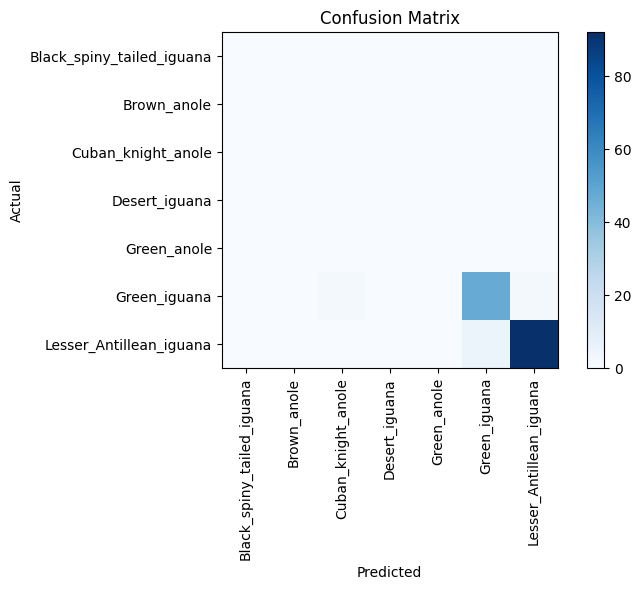

In [ ]:
most_confused = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            most_confused.append((class_names[i], class_names[j], int(cm[i, j])))

most_confused = sorted(most_confused, key=lambda x: x[2], reverse=True)

print("Top 10 most confused:")
for actual, predicted, count in most_confused[:10]:
    print(f"{actual} -> {predicted}: {count}")


plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(NUM_CLASSES), class_names, rotation=90)
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Kaggle Submission
Na het trainen van ons model gebruikten we de testdataset om voorspellingen te maken voor alle ongeziene afbeeldingen. Vervolgens extraheerden we automatisch de juiste ID’s uit de bestandsnamen en combineerden deze met de voorspelde labels in een correct gestructureerd `submission.csv` bestand. Dit bestand werd daarna gebruikt voor onze finale Kaggle submission.

In [ ]:
test_ds = image_dataset_from_directory(
    directory="./test",
    labels=None,
    label_mode=None,
    batch_size=32,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False
)

test_files = test_ds.file_paths

pred_probs = model.predict(test_ds, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

ids = [
    int(os.path.splitext(os.path.basename(path))[0])
    for path in test_files
]

submission_df = pd.DataFrame({
    "id": ids,
    "label": pred_labels
})

submission_df = submission_df.sort_values("id")

submission_df.to_csv("submission.csv", index=False)

print(submission_df.head(15))
print("Opgeslagen als submission.csv")

Found 326 files.
     id  label
0     1      6
111   2      5
222   3      2
260   4      5
271   5      0
282   6      4
293   7      6
304   8      4
315   9      0
1    10      1
12   11      1
23   12      5
34   13      1
45   14      2
56   15      6
Opgeslagen als submission.csv
